In [29]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.chdir("D:/CSV files")
%matplotlib inline

In [30]:
# ─────────────────────────────────────────────
# 1.  LOAD
# ─────────────────────────────────────────────
df_raw = pd.read_csv('Video Games Sales 1980-2024 - Raw.csv')
df_raw

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,11-08-2016,28-01-2019
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,28-02-2019,24-02-2019


In [31]:
# ─────────────────────────────────────────────
# 2.  DATA CLEANING
# ─────────────────────────────────────────────

# --- Drop helper columns not needed for analysis ---
df = df_raw.drop(columns=['img', 'last_update'], errors='ignore').copy()

# --- Parse release_date → year (integer) ---
df['release_date'] = pd.to_datetime(df['release_date'], dayfirst=True, errors='coerce')
df['year'] = df['release_date'].dt.year.astype('Int64')   # nullable int

# --- Drop rows where year is completely unknown (too ambiguous to use) ---
df = df.dropna(subset=['year'])

# --- Keep only reasonable release years 1980-2024 ---
df = df[(df['year'] >= 1980) & (df['year'] <= 2024)]

# --- Fill missing numeric sales with 0 (game was not sold in that region) ---
sales_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'total_sales']
df[sales_cols] = df[sales_cols].fillna(0)

# --- For total_sales still zero, recompute from regional sales ---
mask = df['total_sales'] == 0
df.loc[mask, 'total_sales'] = (
    df.loc[mask, ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].sum(axis=1)
)

# --- Fill missing critic_score with the median per genre ---
df['critic_score'] = df.groupby('genre')['critic_score'].transform(
    lambda x: x.fillna(x.median())
)
# Any remaining NaNs get the global median
df['critic_score'] = df['critic_score'].fillna(df['critic_score'].median())

# --- Fill missing developer with publisher ---
df['developer'] = df['developer'].fillna(df['publisher'])

# --- Drop rows where title/genre/publisher are still missing ---
df = df.dropna(subset=['title', 'genre', 'publisher'])

# --- Remove exact duplicate rows ---
df = df.drop_duplicates()

# --- Cast year to int ---
df['year'] = df['year'].astype(int)

print(f"Clean shape : {df.shape}")
print(f"Missing after cleaning:\n{df[['critic_score','total_sales','na_sales','jp_sales','pal_sales','other_sales']].isnull().sum()}")

Clean shape : (56875, 13)
Missing after cleaning:
critic_score    0
total_sales     0
na_sales        0
jp_sales        0
pal_sales       0
other_sales     0
dtype: int64


In [32]:
# ─────────────────────────────────────────────
# 3.  PALETTE & STYLE
# ─────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font='DejaVu Sans')
ACCENT   = '#4C72B0'
PALETTE  = sns.color_palette('tab10', 10)

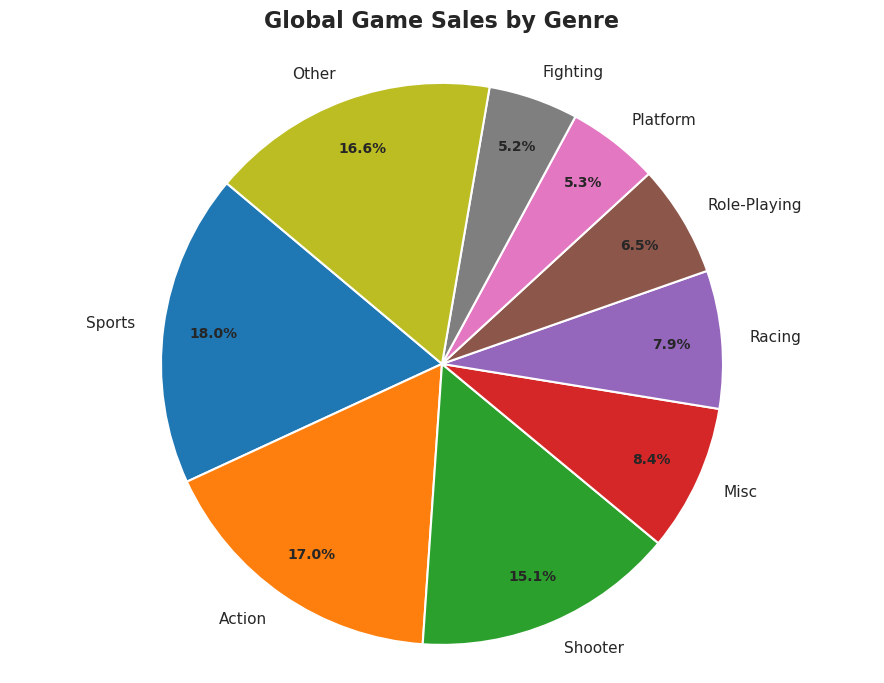

In [33]:
# ═══════════════════════════════════════════
#  DIAGRAM 1  –  PIE CHART
#  Share of total global sales by genre
# ═══════════════════════════════════════════

# Your data preparation
top_genres = genre_sales.head(8)
others = genre_sales.iloc[8:].sum()
pie_data = pd.concat([top_genres, pd.Series({'Other': others})])

# Plot
fig1, ax1 = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax1.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('tab10', len(pie_data)),
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for t in autotexts:
    t.set_fontsize(10)
    t.set_weight('bold')

ax1.set_title('Global Game Sales by Genre', fontsize=16, fontweight='bold', pad=20)
ax1.axis('equal')
plt.tight_layout()
plt.show()

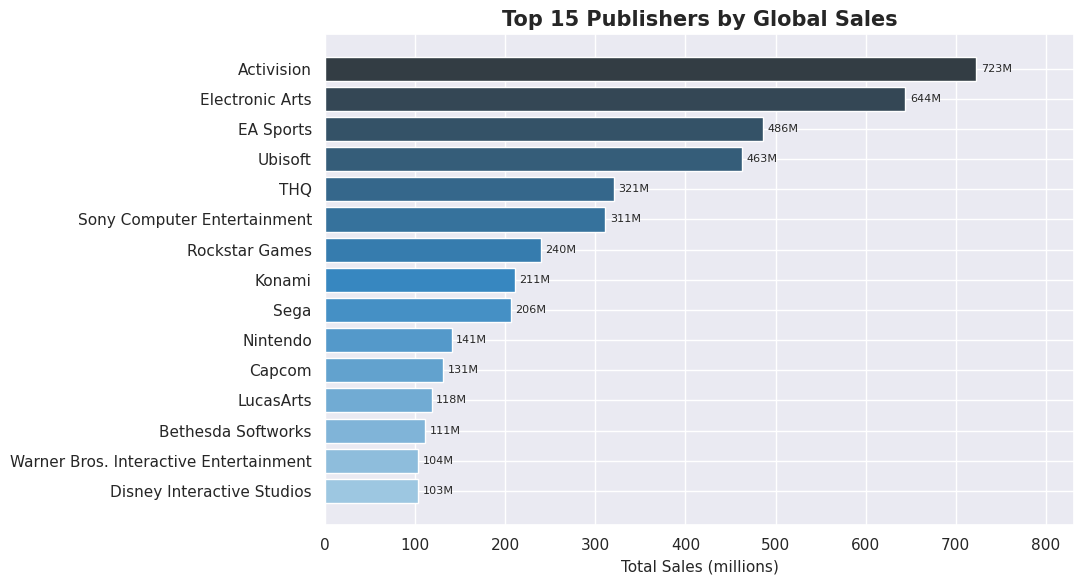

In [34]:
# ═══════════════════════════════════════════
#  DIAGRAM 2  –  BAR CHART
#  Top 15 publishers by total sales
# ═══════════════════════════════════════════
pub_sales = (
    df.groupby('publisher')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig2, ax2 = plt.subplots(figsize=(11, 6))
bars = ax2.barh(pub_sales.index[::-1], pub_sales.values[::-1],
                color=sns.color_palette('Blues_d', 15))
ax2.set_xlabel('Total Sales (millions)', fontsize=11)
ax2.set_title('Top 15 Publishers by Global Sales', fontsize=15, fontweight='bold')
for bar, val in zip(bars, pub_sales.values[::-1]):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}M', va='center', fontsize=8)
ax2.set_xlim(0, pub_sales.max() * 1.15)
fig2.tight_layout()
plt.show()

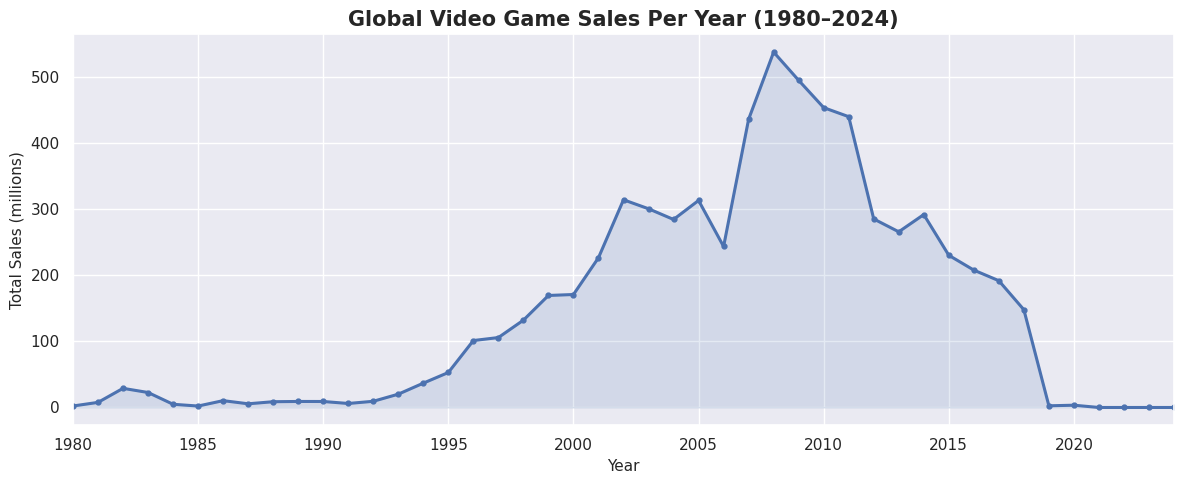

In [35]:
# ═══════════════════════════════════════════
#  DIAGRAM 3  –  LINE CHART
#  Total global game sales per year
# ═══════════════════════════════════════════
yearly = df.groupby('year')['total_sales'].sum().reset_index()

fig3, ax3 = plt.subplots(figsize=(12, 5))
ax3.plot(yearly['year'], yearly['total_sales'], color=ACCENT,
         linewidth=2.2, marker='o', markersize=3.5)
ax3.fill_between(yearly['year'], yearly['total_sales'], alpha=0.15, color=ACCENT)
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Total Sales (millions)', fontsize=11)
ax3.set_title('Global Video Game Sales Per Year (1980–2024)', fontsize=15, fontweight='bold')
ax3.set_xlim(yearly['year'].min(), yearly['year'].max())
fig3.tight_layout()
plt.show()

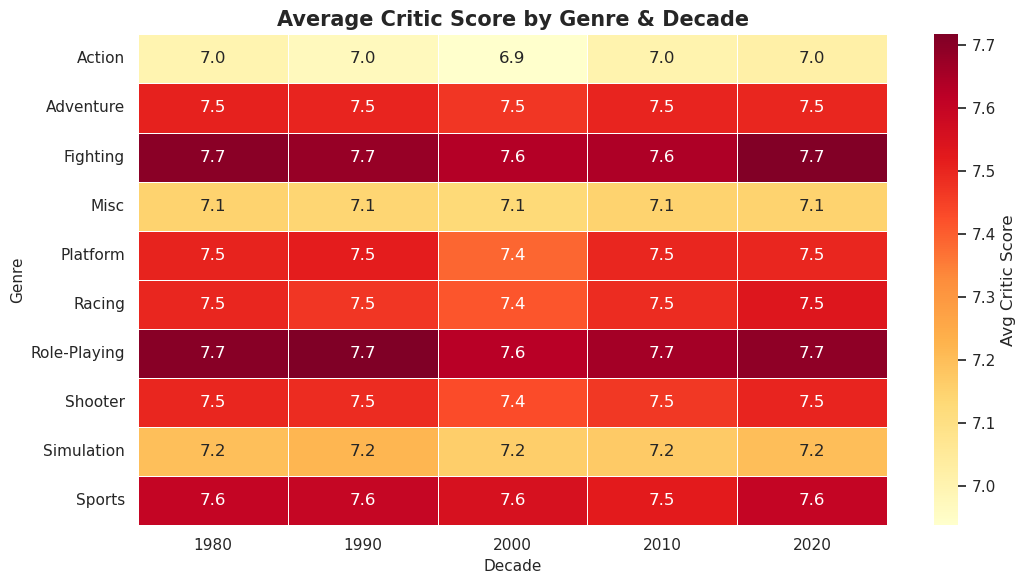

In [37]:
# ═══════════════════════════════════════════
#  DIAGRAM 4  –  HEATMAP
#  Avg critic score: Genre × Decade
# ═══════════════════════════════════════════
df['decade'] = (df['year'] // 10) * 10
top_genre_list = genre_sales.head(10).index.tolist()
heat_df = df[df['genre'].isin(top_genre_list)].copy()
heat_pivot = heat_df.pivot_table(
    values='critic_score',
    index='genre',
    columns='decade',
    aggfunc='mean'
)

fig4, ax4 = plt.subplots(figsize=(11, 6))
sns.heatmap(
    heat_pivot, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=0.4,
    ax=ax4, cbar_kws={'label': 'Avg Critic Score'}
)
ax4.set_title('Average Critic Score by Genre & Decade', fontsize=15, fontweight='bold')
ax4.set_xlabel('Decade', fontsize=11)
ax4.set_ylabel('Genre', fontsize=11)
fig4.tight_layout()
plt.show()


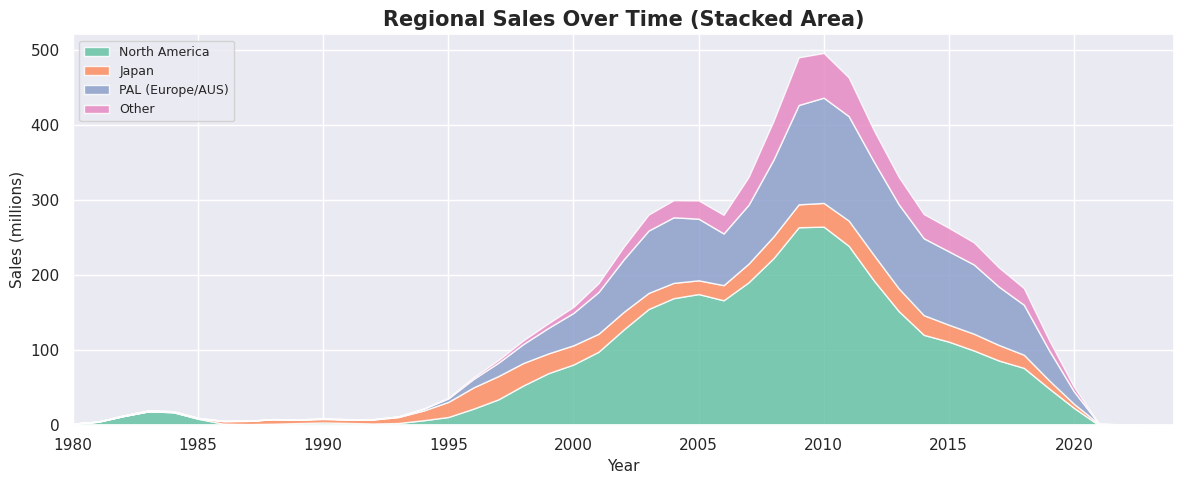

In [38]:
# ═══════════════════════════════════════════
#  DIAGRAM 5  –  STACKED AREA CHART
#  Regional sales breakdown over years
# ═══════════════════════════════════════════
region_year = (
    df.groupby('year')[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']]
    .sum()
    .reset_index()
)
# Smooth with rolling mean
for col in ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']:
    region_year[col] = region_year[col].rolling(3, min_periods=1).mean()

fig5, ax5 = plt.subplots(figsize=(12, 5))
ax5.stackplot(
    region_year['year'],
    region_year['na_sales'],
    region_year['jp_sales'],
    region_year['pal_sales'],
    region_year['other_sales'],
    labels=['North America', 'Japan', 'PAL (Europe/AUS)', 'Other'],
    colors=sns.color_palette('Set2', 4),
    alpha=0.85
)
ax5.set_xlabel('Year', fontsize=11)
ax5.set_ylabel('Sales (millions)', fontsize=11)
ax5.set_title('Regional Sales Over Time (Stacked Area)', fontsize=15, fontweight='bold')
ax5.legend(loc='upper left', fontsize=9)
ax5.set_xlim(region_year['year'].min(), region_year['year'].max())
fig5.tight_layout()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'shot'

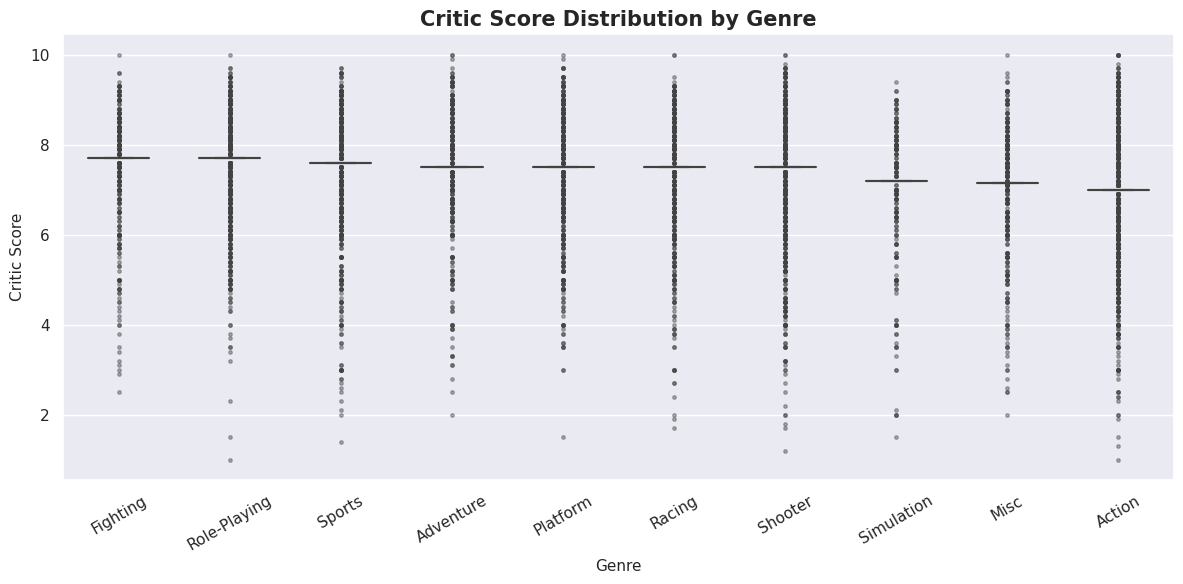

In [39]:
# ═══════════════════════════════════════════
#  DIAGRAM 6  –  BOX PLOT
#  Critic score distribution per top genre
# ═══════════════════════════════════════════
box_df = df[df['genre'].isin(top_genre_list)].copy()
genre_order = (
    box_df.groupby('genre')['critic_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig6, ax6 = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=box_df, x='genre', y='critic_score',
    order=genre_order,
    palette='husl', width=0.55,
    flierprops=dict(marker='o', markersize=2.5, alpha=0.4),
    ax=ax6
)
ax6.set_xlabel('Genre', fontsize=11)
ax6.set_ylabel('Critic Score', fontsize=11)
ax6.set_title('Critic Score Distribution by Genre', fontsize=15, fontweight='bold')
ax6.tick_params(axis='x', rotation=30)
fig6.tight_layout()
plt.shot()

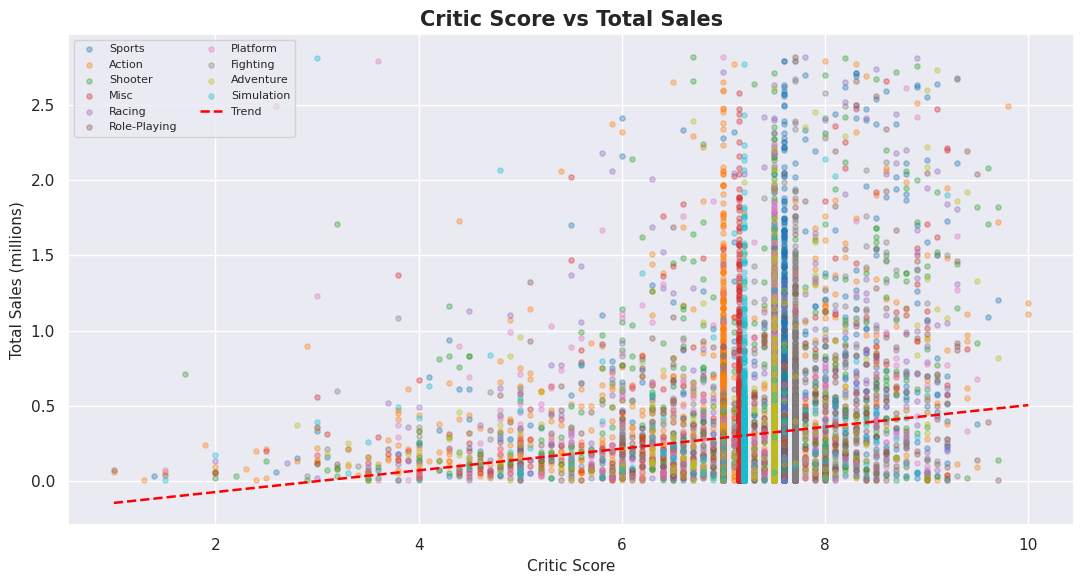

In [40]:
# ═══════════════════════════════════════════
#  DIAGRAM 7  –  SCATTER PLOT
#  Critic score vs Total sales (top genres)
# ═══════════════════════════════════════════
scatter_df = df[
    (df['genre'].isin(top_genre_list)) &
    (df['critic_score'] > 0) &
    (df['total_sales'] > 0) &
    (df['total_sales'] < df['total_sales'].quantile(0.995))  # remove extreme outliers
].copy()

fig7, ax7 = plt.subplots(figsize=(11, 6))
genre_palette = dict(zip(top_genre_list, sns.color_palette('tab10', len(top_genre_list))))
for g in top_genre_list:
    sub = scatter_df[scatter_df['genre'] == g]
    ax7.scatter(sub['critic_score'], sub['total_sales'],
                label=g, alpha=0.35, s=14, color=genre_palette[g])

# Trend line
m, b = np.polyfit(scatter_df['critic_score'], scatter_df['total_sales'], 1)
xs = np.linspace(scatter_df['critic_score'].min(), scatter_df['critic_score'].max(), 200)
ax7.plot(xs, m*xs + b, color='red', linewidth=1.8, linestyle='--', label='Trend')

ax7.set_xlabel('Critic Score', fontsize=11)
ax7.set_ylabel('Total Sales (millions)', fontsize=11)
ax7.set_title('Critic Score vs Total Sales', fontsize=15, fontweight='bold')
ax7.legend(fontsize=8, ncol=2, loc='upper left')
fig7.tight_layout()
plt.show()

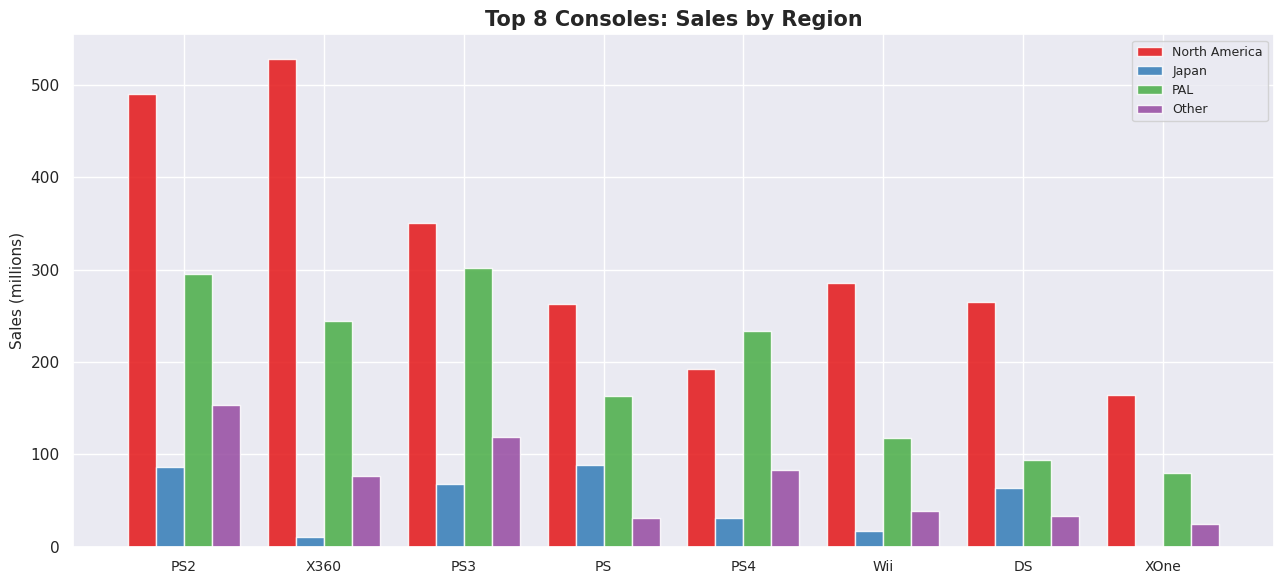

In [42]:
# ═══════════════════════════════════════════
#  DIAGRAM 8  –  GROUPED BAR CHART
#  Top 8 consoles: sales split by region
# ═══════════════════════════════════════════
top_consoles = (
    df.groupby('console')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)
console_region = (
    df[df['console'].isin(top_consoles)]
    .groupby('console')[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']]
    .sum()
    .loc[top_consoles]
)

x    = np.arange(len(top_consoles))
w    = 0.20
cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
lbls = ['North America', 'Japan', 'PAL', 'Other']
col_colors = sns.color_palette('Set1', 4)

fig8, ax8 = plt.subplots(figsize=(13, 6))
for i, (col, lbl, col_c) in enumerate(zip(cols, lbls, col_colors)):
    ax8.bar(x + i*w, console_region[col], width=w, label=lbl, color=col_c, alpha=0.87)

ax8.set_xticks(x + 1.5*w)
ax8.set_xticklabels(top_consoles, fontsize=10)
ax8.set_ylabel('Sales (millions)', fontsize=11)
ax8.set_title('Top 8 Consoles: Sales by Region', fontsize=15, fontweight='bold')
ax8.legend(fontsize=9)
fig8.tight_layout()
plt.show()